In [73]:
import numpy as np
import matplotlib.pyplot as plt
import gurobipy as gp
from gurobipy import GRB
from util.distance import *
#from util.tour import *
from data_loader import *
from itertools import permutations, combinations, product
import math

In [74]:
# Configs
# number of routes
r=1

# either config port and station indices or test problem id

test_problem = 2
catch_capacity = [7000,8000]

n_boats = len(catch_capacity)
dist_limit = 30
n_dummy_port = 3

node_compress = True
max_work = 20

port_idx, stations_ids, _ = load_test_problem(test_problem)
port_idx = np.array(port_idx)
port_idx, len(stations_ids), stations_ids

(array([12]),
 30,
 array([  9,  10,  11,  12,  13,  14,  61,  62,  63,  64,  65,  66,  67,
         68,  69,  70,  71,  72,  73,  74,  75,  76,  77, 139, 140, 141,
        142, 143, 144,  60]))

In [75]:
import glob
import os

prob_id = 35
notebook_dir = os.path.dirname(os.path.abspath("__file__"))  # in scripts
# In Jupyter, safer to use:
notebook_dir = os.getcwd()  # where kernel started

filename = glob.glob(os.path.join(notebook_dir, "new_test_problems", f"test_problem{prob_id:02d}*"))[0]
# print(filename)
with open(filename, "r") as f:
    result = f.read()
split = result.split('; ')
stations_ids = np.array(eval(split[0]))
port_idx = np.array(eval(split[1]))
n_boats = int(split[2])
catch_capacity = np.array(eval(split[3]))
dist_limit = int(split[4])
max_work = int(split[5])

In [76]:
island_data = load_island_data()
nodes, n_ports, n_stations = load_nodes()
# dist = load_true_dist()
dist = np.load("local data/true_time.npy")
dummy_start = n_ports + 2 * n_stations
catch = load_catch_fixed_random_assignment().to_numpy()
# index of nodes
index = np.arange(nodes.shape[0])

In [77]:
ports_idx = port_idx

station_idx = stations_ids * 2 + n_ports
stations_idx = np.stack([stations_ids * 2, stations_ids * 2 + 1]).T.reshape(-1) + n_ports

dummy_idx = []

counter=0
for port in range(len(ports_idx)):
    for i in range(n_dummy_port):
        dummy_idx.append(dummy_start + counter)
        counter = counter + 1

dummy_idx = np.array(dummy_idx)

# indices go [ports, stations, dummies]

distance_working = np.zeros([dummy_start + counter,dummy_start + counter])
distance_working[0:dummy_start,0:dummy_start] = dist # copy true dist matrix except for dummies

for port in range(len(ports_idx)):
    for i in range(n_dummy_port):
        distance_working[dummy_start + i + port * n_dummy_port,0:dummy_start]\
            = dist[ports_idx[port], 0:dummy_start]
        distance_working[0:dummy_start,dummy_start + i + port * n_dummy_port]\
            = dist[0:dummy_start,ports_idx[port]]

for i in range(counter):
    for j in range(counter):
        distance_working[dummy_start + i, dummy_start + j] = \
            dist[ports_idx[math.floor(i/n_dummy_port)], ports_idx[math.floor(j/n_dummy_port)]]

dist = distance_working # true distance matrix with distances for dummy nodes (i think they're the same as the ports??)

display(distance_working)

array([[ 0.        ,  8.81693511, 11.9033058 , ..., 21.29430449,
        21.29430449, 21.29430449],
       [ 8.81693511,  0.        ,  3.2753435 , ..., 29.97625023,
        29.97625023, 29.97625023],
       [11.9033058 ,  3.2753435 ,  0.        , ..., 33.11047301,
        33.11047301, 33.11047301],
       ...,
       [21.29430449, 29.97625023, 33.11047301, ...,  0.        ,
         0.        ,  0.        ],
       [21.29430449, 29.97625023, 33.11047301, ...,  0.        ,
         0.        ,  0.        ],
       [21.29430449, 29.97625023, 33.11047301, ...,  0.        ,
         0.        ,  0.        ]], shape=(1178, 1178))

In [78]:
# route1 = [12, 301, 302, 168, 167, 159, 160, 166, 165, 39, 40, 37, 38, 41, 42, 162, 161, 164, 163, 155, 156, 12]
# route2 = [12, 151, 152, 153, 154, 157, 158, 35, 36, 33, 34, 31, 32, 150, 149, 12]
# broute1 = [route1[len(route1)-i-1] for i in range(len(route1))]
# broute2 = [route2[len(route2)-i-1] for i in range(len(route2))]

# dist_dict = {}
# catch_dict = {}
# for (i, j) in permutations(route1+route2, 2):
#     dist_dict[(i, j)] = dist[i][j]

# total = 0
# for i in range(len(broute1)-1):
#     total += dist_dict[(broute1[i], broute1[i+1])]
# for i in range(len(broute2)-1):
#     total += dist_dict[(broute2[i], broute2[i+1])]
# print(total)

# total = 0
# for i in range(len(broute1)-1):
#     total += dist[broute1[i], broute1[i+1]]
# for i in range(len(broute2)-1):
#     total += dist[broute2[i], broute2[i+1]] 
# print(total)

# total = 0
# for i in range(len(route1)-1):
#     total += dist[route1[i], route1[i+1]]
# for i in range(len(route2)-1):
#     total += dist[route2[i], route2[i+1]] 
# print(total)

# print([route1[len(route1)-i-1] for i in range(len(route1))])

In [79]:
if n_dummy_port == 0:
    node_idx = np.concatenate([port_idx, station_idx]) #
    nodes_idx = np.concatenate([ports_idx, stations_idx])#
else:
    node_idx = np.concatenate([port_idx, station_idx, dummy_idx]) #
    nodes_idx = np.concatenate([ports_idx, stations_idx, dummy_idx])#

In [80]:
dist[nodes_idx, :].shape

(44, 1178)

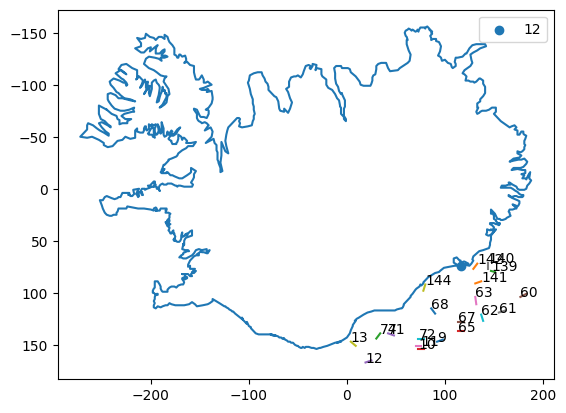

In [81]:

plt.plot(*degArr2point(island_data))
# plot ports
for idx in ports_idx:
    plt.scatter(*degArr2point(nodes[[idx]]), label=str(idx))
# plot stations
for id in stations_ids:
    station = nodes[[id * 2 + n_ports, id * 2 + 1 + n_ports], :]
    plt.plot(*degArr2point(station))
    plt.annotate(id, degArr2point(station[[0], :]).flatten())
plt.legend()
plt.gca().invert_yaxis()

In [82]:
M = 1000
dist_dict = {}
catch_dict = {}
for (i, j) in permutations(nodes_idx, 2):
    dist_dict[(i, j)] = dist[i][j]
    if abs(i-j) == 1 and i <= 1174 and j <= 1174 and i >=13 and j>=13 and ((i<j and i%2 == 1) or (i>j and j%2 == 1)):
        catch_dict[(i, j)] = float(catch[int (math.floor((i-13)/2))])

m = gp.Model()
home_port = ports_idx[0]

Xs = m.addVars(dist_dict.keys(), obj=dist_dict, vtype=GRB.BINARY, name="x")

#forced visits

# Each station is visited once (one leaving arc)
m.addConstrs((Xs.sum(i, '*') == 1 for i in stations_idx), name="once")
# The tow has to be selected
m.addConstrs((Xs.sum(i, j) + Xs.sum(j, i) == 1 for (i, j) in stations_idx.reshape(-1, 2)), name="tow") #check

# All routes start at designated port
# m.addConstr(Xs.sum(home_port, '*') <= n_boats, name="homeout")
# # All routes end at designated port
# m.addConstr(Xs.sum('*', home_port) <= n_boats, name="homein")

port_dummy_no_home_idx = np.concatenate([ports_idx[1:], dummy_idx])
# Each dummy node is visited at most once (one leaving arc)
m.addConstrs((Xs.sum(i, '*') <= 1 for i in port_dummy_no_home_idx), name="onceDummy")

# All routes that go to node must leave node
m.addConstrs((Xs.sum('*', i) - Xs.sum(i, '*') == 0 for i in nodes_idx), name="flow")

None

C:\Users\saahi\AppData\Local\Temp\ipykernel_26112\3599998566.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  catch_dict[(i, j)] = float(catch[int (math.floor((i-13)/2))])


In [83]:
node_idx_no_home = np.concatenate([ports_idx[1:], station_idx, dummy_idx])

port_dummy_idx = np.concatenate([ports_idx, dummy_idx])


# subtour elimination
station_pairs = [
    (i,j) for i, j in product(node_idx_no_home, node_idx) if i != j
]

Ys = m.addVars(node_idx_no_home, node_idx, name="y")
m.addConstrs((
        Xs.sum(i, j) == Ys[i,j] \
        if np.isin([j],port_dummy_idx) and np.isin([i],port_dummy_idx) else \
        Xs.sum(i, j) + Xs.sum(i + 1, j) == Ys[i,j] \
        if np.isin([j],port_dummy_idx) else \
        Xs.sum(i, j) + Xs.sum(i, j + 1) == Ys[i,j]\
        if np.isin([i],port_dummy_idx) else \
        Xs.sum(i, j) + Xs.sum(i + 1, j) +\
        Xs.sum(i, j + 1) + Xs.sum(i + 1, j + 1) == Ys[i,j] \
        for i, j in station_pairs ), name="compressGG"
    )

Zs = m.addVars(node_idx_no_home, node_idx, name="z")

m.addConstrs(
    (Zs.sum(i, '*') - Zs.sum('*', i) == 1 for i in station_idx) , name="GGplusoneStation"
)
m.addConstrs(
    (Zs.sum(i, '*') - Zs.sum('*', i) == Ys.sum(i, '*')  for i in port_dummy_no_home_idx) , name="GGplusoneDummyports"
)
m.addConstrs(
    (Zs[i,j] <=(max_work + n_dummy_port/n_boats) * Ys[i,j] for i in node_idx_no_home for j in node_idx) , name="GGbigM"
)
#len(nodes_idx)
None

In [84]:
#capacity variables

if node_compress:
    cap_dict = {}
    for i in node_idx_no_home:
        for k in range(n_boats):
            cap_dict[(home_port, i, k)] = catch_capacity[k]


    #def bin vars
    Bs = m.addVars([home_port],node_idx_no_home,range(n_boats), vtype=GRB.BINARY, name="b") # 1 if arc from hp to node j for boat k
    #bin constraints
    #max one boat per arc
    m.addConstrs((Bs.sum(home_port, j, '*') <= 1 for j in node_idx_no_home), name="oneboatperarc")
    #max one arc per boat
    m.addConstrs((Bs.sum(home_port, '*', k) <= 1 for k in range(n_boats)), name="onearcperboat")
    # boat can only travel if path is selected
    m.addConstrs((Bs[home_port,j,k] <= Xs[home_port,j] + Xs[home_port,j+1] for j in station_idx for k in range(n_boats)) , name="boatifpathselected_compress_station")
    m.addConstrs((Bs[home_port,j,k] <= Xs[home_port,j] for j in port_dummy_no_home_idx for k in range(n_boats)), name="Boatifpathselected_compress_port")

    #def flow
    Es = m.addVars(node_idx_no_home,node_idx, name = 'e')
    #flow constraints
    # pass the flow on
    m.addConstrs((Es.sum(i,'*') - (Es.sum('*', i) + Bs.prod(cap_dict,home_port,i,'*')) == 0 for i in node_idx_no_home), name="Capacitytransfer")
    # limited by Xs
    maxCap = max(catch_capacity)
    m.addConstrs(
        (Es[i,j] <= maxCap * Xs[i,j] \
            if np.isin([j],port_dummy_idx) and np.isin([i],port_dummy_idx) else \
                Es[i,j] <= maxCap * Xs[i,j] + maxCap * Xs[i,j + 1] \
            if np.isin([i],port_dummy_idx) else\
                Es[i,j] <= maxCap * Xs[i,j] + maxCap * Xs[i + 1,j] \
            if np.isin([j],port_dummy_idx) else\
                Es[i,j] <= maxCap * Xs[i,j] + maxCap * Xs[i + 1,j] +\
                maxCap * Xs[i,j + 1] + maxCap * Xs[i + 1,j + 1]  \
            for i, j in station_pairs), name="Capacitytransferif_x_compress"
    )
else:
    nodes_idx_no_home = np.concatenate([ports_idx[1:], stations_idx, dummy_idx])
    stations_pairs = [
    (i,j) for i, j in product(nodes_idx_no_home, nodes_idx) if i != j
]

    cap_dict = {}
    for i in nodes_idx_no_home:
        for k in range(n_boats):
            cap_dict[(home_port, i, k)] = catch_capacity[k]


    #def bin vars
    Bs = m.addVars([home_port],nodes_idx_no_home,range(n_boats), vtype=GRB.BINARY, name="b")
    #bin constraints
    #max one boat per arc
    m.addConstrs((Bs.sum(home_port, j, '*') <= 1 for j in nodes_idx_no_home), name="oneboatperarc")
    #max one arc per boat
    m.addConstrs((Bs.sum(home_port, '*', k) <= 1 for k in range(n_boats)), name="onearcperboat")
    # boat can only travel if path is selected
    m.addConstrs((Bs[home_port,j,k] <= Xs[home_port,j] for j in nodes_idx_no_home for k in range(n_boats)), name="boatifpathselected_uncompress")
    #m.addConstr(Bs[home_port,301,0] == 1)
    #m.addConstr(Bs[home_port,149,1] == 1)

    #def flow
    Es = m.addVars(nodes_idx_no_home,nodes_idx, name = 'e')
    #flow constraints
    # pass the flow on
    m.addConstrs((Es.sum(i,'*') - (Es.sum('*', i) + Bs.prod(cap_dict,home_port,i,'*')) == 0 for i in nodes_idx_no_home), name="capacitytrasfer")
    # limited by Xs
    maxCap = max(catch_capacity)
    m.addConstrs((Es[i,j] <= maxCap * Xs[i,j] for i, j in stations_pairs), name="capacityflowif_x")


None

In [85]:
#catch cap
station_pairs2 = [
(i,j) for i, j in product(station_idx, node_idx) if i != j
]

Cs = m.addVars(station_idx, node_idx, name="c") # cs are ws
m.addConstrs(
        Xs.sum(i, j) + Xs.sum(i + 1, j) == Cs[i,j] \
        if np.isin([j],port_dummy_idx) else \
        Xs.sum(i, j) + Xs.sum(i + 1, j) +\
        Xs.sum(i, j + 1) + Xs.sum(i + 1, j + 1) == Cs[i,j] \
        for i, j in station_pairs2
    )

Ps = m.addVars(station_idx, node_idx, name="p")

m.addConstrs(
    Ps.sum(i, '*') - Ps.sum('*', i) == catch[int((i-13)/2)] for i in station_idx #need to change to catch at i
)
if node_compress:
    m.addConstrs(
        Ps[i,j] <= Es[i,j] for i in station_idx for j in node_idx
    )
else:
    m.addConstrs(
        Ps[i,j] <= Es[i,j] + Es[i + 1,j]  \
        if np.isin([j],port_dummy_idx) else
        Ps[i,j] <= Es[i,j] + Es[i + 1,j] + Es[i,j + 1] + Es[i + 1,j + 1]
        for i in station_idx for j in node_idx
    )
None

C:\Users\saahi\AppData\Local\Temp\ipykernel_26112\3902854855.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  m.addConstrs(


In [86]:
#dist cap
#note: this doesn't start counting distance until the first station is started
#      this is intentional as it doesn't need to consider the fish rotting if there
#      are no fish on board. It does start at the start of the first tow, so a 4
#      nautical mile correction factor is included later
Ds = m.addVars(station_idx, node_idx, name="d") #ds are es
m.addConstrs(
        Xs.sum(i, j) * dist[i,j] + Xs.sum(i + 1, j)  * dist[i+1,j] + \
        Xs.sum(i,j) * dist[i+1,i] + Xs.sum(i+1,j) * dist[i,i+1] == Ds[i,j] \
        if np.isin([j],port_dummy_idx) else \
        Xs.sum(i, j)  * dist[i,j] + Xs.sum(i + 1, j) * dist[i+1,j] +\
        Xs.sum(i, j + 1) * dist[i,j+1] + Xs.sum(i + 1, j + 1) * dist[i+1,j+1] + \
        (Xs.sum(i,j) + Xs.sum(i,j+1)) * dist[i+1,i] + \
        (Xs.sum(i+1,j) + Xs.sum(i+1,j+1)) * dist[i,i+1]== Ds[i,j] \
        for i, j in station_pairs2
    )

Ts = m.addVars(station_idx, node_idx, name="t")

m.addConstrs(
    Ts.sum(i, '*') - Ts.sum('*', i) == Ds.sum(i,'*') for i in station_idx
)
m.addConstrs(
    # Ts[i,j] <=(dist_limit + 7.4) * Cs[i,j] for i in station_idx for j in node_idx
    Ts[i,j] <=(dist_limit) * Cs[i,j] for i in station_idx for j in node_idx
)


# m.optimize()
None

In [87]:
print(len(Xs))

1892


In [88]:
m.update()


In [89]:
# m.Params.MIPGap = 0.05
# m.Params.MIPFocus = 2
m.Params.WorkLimit = 100

Set parameter WorkLimit to value 100


In [90]:
m.reset()

Discarded solution information


In [91]:
# route1 = [12, 301, 302, 168, 167, 159, 160, 166, 165, 39, 40, 37, 38, 41, 42, 162, 161, 163, 164, 155, 156, 12]
# route1 = [route1[len(route1)-i-1] for i in range(len(route1))]
# route2 = [12, 151, 152, 153, 154, 157, 158, 35, 36, 33, 34, 31, 32, 150, 149, 12]
# route = [12, 301, 302, 168, 167, 159, 160, 166, 165, 39, 40, 37, 38, 41, 42, 162, 161, 163, 164, 155, 156, dummy_start, 151, 152, 153, 154, 157, 158, 35, 36, 33, 34, 31, 32, 150, 149, 12]
# [12, 149, 150,us 32, 31, 34, 33, 36, 35, 158, 157, 154, 153, 152, 151, 1177]
# [1178, 1176, 156, 155, 163, 164, 161, 162, 42, 41, 38, 37, 40, 39, 165, 166, 160, 159, 167, 168, 302, 301]
# route1 = [np.int64(168), np.int64(167), np.int64(159), np.int64(160), np.int64(166), np.int64(165), np.int64(39), np.int64(40), np.int64(37), np.int64(38), np.int64(41), np.int64(42), np.int64(162), np.int64(161), np.int64(163), np.int64(164), np.int64(155), np.int64(156), np.int64(154), np.int64(153), np.int64(152), np.int64(151)]
# route2 = [np.int64(32), np.int64(31), np.int64(34), np.int64(33), np.int64(36), np.int64(35), np.int64(157), np.int64(158), np.int64(150), np.int64(149), np.int64(302), np.int64(301)]
# route = route1 + [12] + route2
# print(dist[12, 168])
# print(len(route1))
# print(len(route2))
# # for i in range(0, len(route)-1):
# #     if i == 5:
# #         continue
# #     Xs[route[i], route[i+1]].UB = 1
# #     Xs[route[i], route[i+1]].LB = 1
# for i in range(0, len(route1)-1):
#     Xs[route1[i], route1[i+1]].UB = 1
#     Xs[route1[i], route1[i+1]].LB = 1
# for i in range(0, len(route2)-1):
#     Xs[route2[i], route2[i+1]].UB = 1
#     Xs[route2[i], route2[i+1]].LB = 1
#     # Xs[route[i], route[i+1]].start = 1

In [ ]:
x_percent = 50 # remove longest x% of arcs

for i in stations_idx:
    # Get outgoing arcs (i, j), excluding self-loop
    outgoing = [(j, dist[i, j]) for j in stations_idx if i != j and (abs(i-j) > 1 or (i>j and i%2==1) or (i<j and i%2==0))]

    # Sort by travel time descending
    outgoing_sorted = sorted(outgoing, key=lambda x: x[1], reverse=True)

    # Determine how many to remove
    num_to_remove = min(int(np.ceil(x_percent * len(outgoing))), len(outgoing)-3)
    # num_to_remove = int(np.ceil(x_percent * len(outgoing)))

    # Remove longest arcs
    for j, _ in outgoing_sorted[:num_to_remove]:
        if (i, j) in Xs:
            # Xs[i, j].lb = 0
            # Xs[i, j].ub = 0
            m.remove(Xs[i, j])
            del Xs[i, j]


In [93]:
m.optimize()


Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (win64 - Windows 11.0 (26100.2))

CPU model: AMD Ryzen 3 7330U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
WorkLimit  100

Optimize a model with 3730 rows, 3971 columns and 11450 nonzeros
Model fingerprint: 0x013ce105
Variable types: 3576 continuous, 395 integer (395 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+04]
  Objective range  [7e-01, 1e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 2e+03]
Presolve removed 3178 rows and 3221 columns
Presolve time: 0.03s
Presolved: 552 rows, 750 columns, 2771 nonzeros
Variable types: 375 continuous, 375 integer (375 binary)

Root relaxation: objective 2.643582e+02, 366 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node

In [94]:
# m.tune()
# m.computeIIS()
print(m.Work)

0.03624031688089092


In [95]:
# m.printAttr('X')
# const_list = []
# for c in m.getConstrs():
#    if c.IISConstr:
#     #    print(c.ConstrName)
#         const_list.append(c.ConstrName)
# print(const_list)

In [96]:
vals = m.getAttr('X', Xs)
vals = [k for (k,v) in vals.items() if v > .5]
vals = [(int(a), int(b)) for a, b in vals]
print(vals)
# vals = m.getAttr('t', Ts)
values = {Ts[i, j].X for i in station_idx for j in node_idx}
print(max(values))

GurobiError: Unable to retrieve attribute 'X'

In [ ]:
from collections import Counter
current = 297
sequence = [297]
while True:
    finished = True
    for a, b in vals:
        if a == current and (b ==12 or b > 1174 or b not in sequence) and b != 298:
            # print(b)
            sequence.append(b)
            current = b
            finished = False
    if finished:
        break
sequence.insert(0, 298)
print(sequence)
print(len(sequence))
print(Counter(sequence))


[298, 297]
2
Counter({298: 1, 297: 1})


In [ ]:
# Step 1: Replace any node > 1174 with 12
# arcs = [(12 if a > 1174 else a, 12 if b > 1174 else b) for a, b in vals]
arcs = vals

# Step 2: Build lookup table from start node -> end node
next_node = {}
for a, b in arcs:
    next_node[a] = b  # assumes at most 1 outgoing arc per node

# Step 3: Build sequence starting from 12
seq = [12]
cur = 12

while cur in next_node:
    nxt = next_node[cur]
    seq.append(nxt)
    cur = nxt
    if len(seq) > len(arcs) + 1:  # safety break for infinite loops
        break

sequences = []
end = True
subseq = []
for i in seq:
    if i == 12 or i > 1174:
        sequences.append(subseq)
        subseq = []
        continue
    subseq.append(i)
    
print(seq)
for sequence in sequences:
    print(sequence)


[12, 1175, 38, 37, 40, 39, 162, 161, 155, 156, 36, 35, 34, 33, 157, 158, 1177, 295, 296, 139, 140, 137, 138, 135, 136, 133, 134, 292, 291, 294, 293, 297, 298, 1176, 301, 302, 149, 150, 147, 148, 144, 143, 32, 31, 12, 1175]
[]
[]
[38, 37, 40, 39, 162, 161, 155, 156, 36, 35, 34, 33, 157, 158]
[295, 296, 139, 140, 137, 138, 135, 136, 133, 134, 292, 291, 294, 293, 297, 298]
[301, 302, 149, 150, 147, 148, 144, 143, 32, 31]
[]


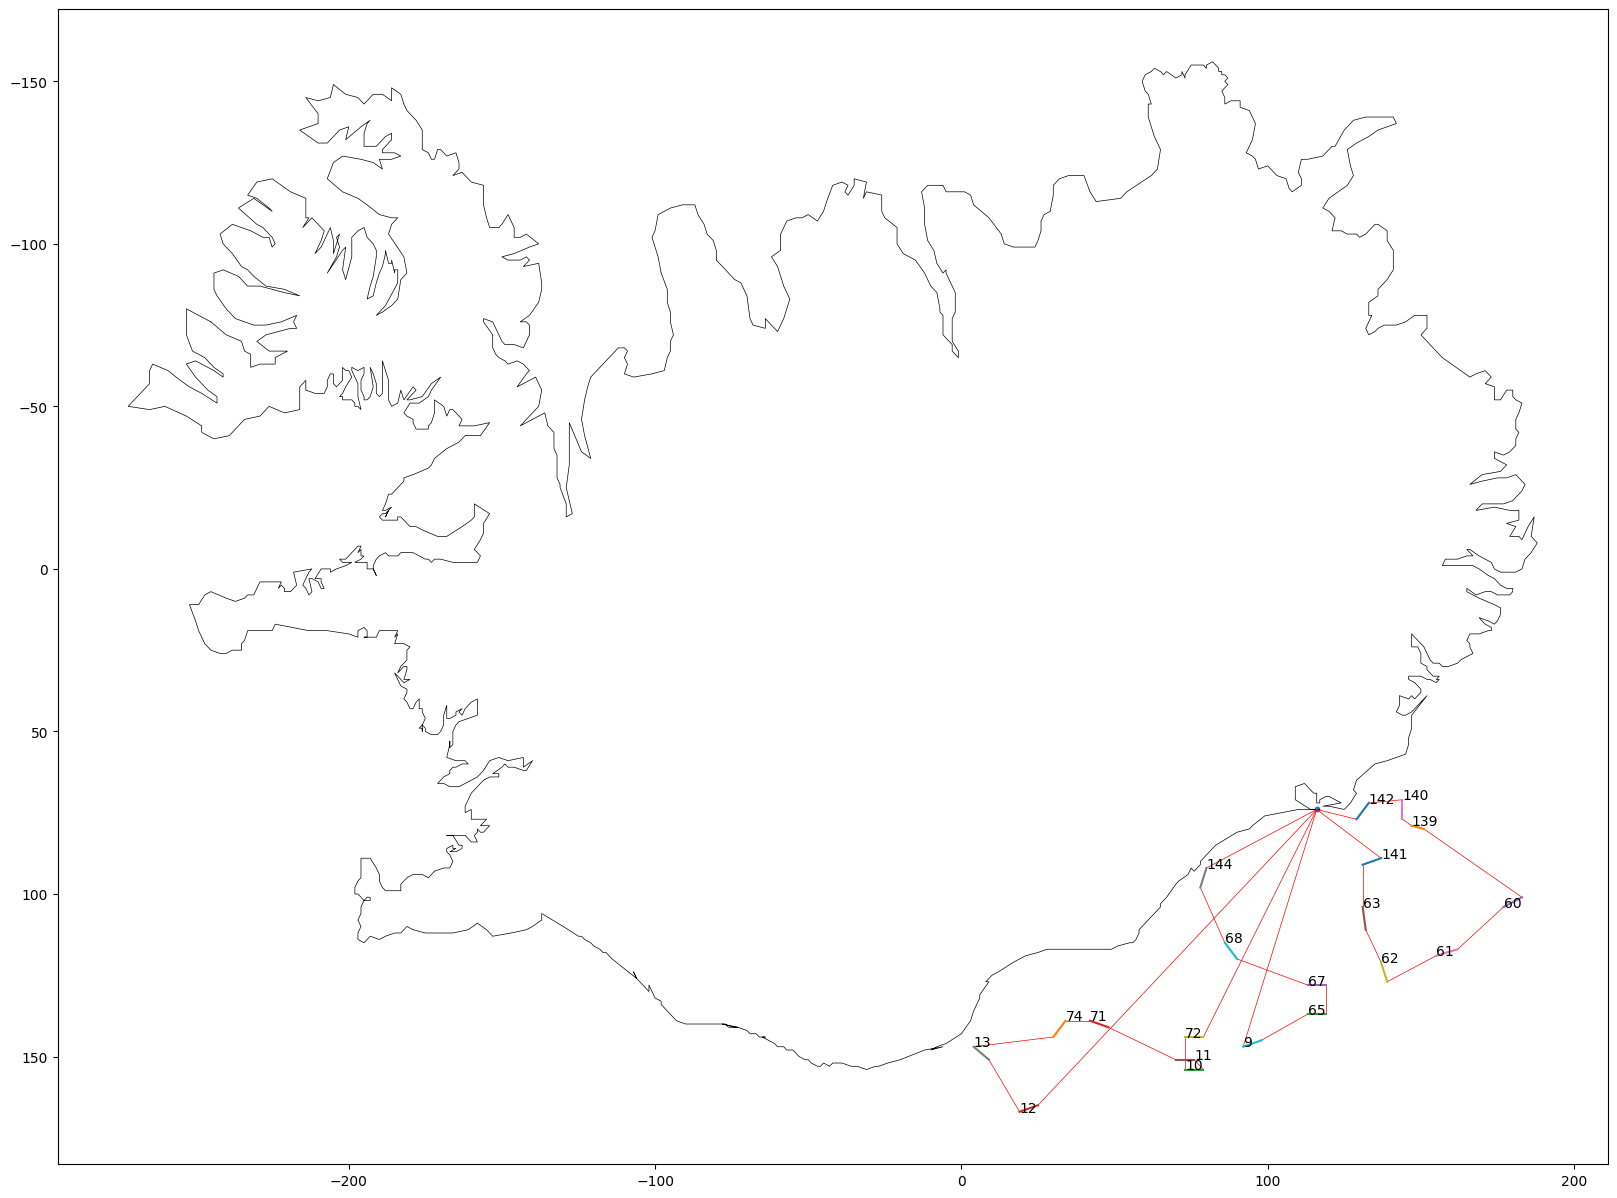

In [ ]:
fig,ax = plt.subplots(figsize=(20,15)) # figsize=(15,13)
ax.plot(*degArr2point(island_data), color="k", linewidth=0.5)
# plot ports
for idx in ports_idx:
    ax.scatter(*degArr2point(nodes[[idx]]), s=10)

#plot routes
colours = ['r-','b-','y-','c-','m-','g-','w-']
k=0
for i, j in vals:
    if i < dummy_start and j < dummy_start:
        ax.plot(*degArr2point(nodes[[i,j]]),  colours[k % 8], linewidth=.5)
    if i >= dummy_start and j < dummy_start:
        ax.plot(*degArr2point(nodes[[ports_idx[math.floor((i-dummy_start)/ n_dummy_port)]  ,j]]),  colours[k % 8], linewidth=.5)
    if i < dummy_start and j >= dummy_start:
        ax.plot(*degArr2point(nodes[[i,ports_idx[math.floor((j-dummy_start)/ n_dummy_port)]]]),  colours[k % 8], linewidth=.5)
    if i >= dummy_start and j >= dummy_start:
        ax.plot(*degArr2point(nodes[[ports_idx[math.floor((i-dummy_start)/ n_dummy_port)] ,ports_idx[math.floor((j-dummy_start)/ n_dummy_port)]]]),  colours[k % 8], linewidth=.5)

# plot stations
for id in stations_ids:
    station = nodes[[id * 2 + n_ports, id * 2 + 1 + n_ports], :]
    ax.plot(*degArr2point(station))
    ax.annotate(id, degArr2point(station[[0], :]).flatten())
# ax.set_xlim([0,120])   
# ax.set_ylim([70,175])     
# ax.get_xaxis().set_visible(False)
# ax.get_yaxis().set_visible(False)
#plt.legend()
plt.gca().invert_yaxis()
    

In [ ]:
# m.write("sample.lp")